# MAI 600 — Module 3: Attention & Transformer Architecture Walkthrough

**Domain:** Business / Finance operations &nbsp;•&nbsp; **Track:** Hybrid (manual annotation **+** real attention from a pretrained Transformer)

**Author:** Lais Santos Silva &nbsp;•&nbsp; **Course:** MAI 600 – Natural Language Processing

---

### What this notebook does
This walkthrough traces a short **finance variance-report** paragraph through every stage of a Transformer, from raw text to output probabilities. The goal is to **show understanding** of how tokens, embeddings, positional information, self-attention (Q/K/V), attention weights, multi-head attention, feed-forward layers, and output probabilities fit together.

It runs on two levels to ground concepts:
1. Manual NumPy example computes an attention step from scratch, so the math is visible.
2. Pre-trained Model where BERT is loaded with `output_attentions=True` to extract and visualize *actual* attention weights on our sentence.

### How to run
- **Google Colab (recommended):** Runtime → *Run all*. The install cell handles dependencies. A GPU is **not** required.
- **Locally:** create a fresh virtual environment and `pip install transformers torch matplotlib pandas numpy`.

> Every model cell is wrapped in a fallback. If `transformers`/`torch` are unavailable or offline, the notebook still runs end-to-end using the manual analysis.

## 0. Install dependencies (Colab)
Skip this cell if the packages are already installed in your environment.

In [1]:
# In Colab, uncomment the next line the first time you run the notebook.
# !pip install -q transformers torch matplotlib pandas numpy
print('If running in Colab and imports fail below, uncomment the pip line above and re-run.')

If running in Colab and imports fail below, uncomment the pip line above and re-run.


## 1. Import libraries

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to load the deep-learning stack. If it is missing or offline, we fall back to
# a fully manual analysis so the notebook still runs top-to-bottom.
try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    MODEL_AVAILABLE = True
    print('transformers + torch available -> ready to run pre-trained model attention.')
except Exception as e:
    MODEL_AVAILABLE = False
    print('Model stack unavailable -> using manual analysis only. Reason:', e)

pd.set_option('display.max_colwidth', 80)

transformers + torch available -> ready to run pre-trained model attention.


## 2. Define the text sample

A **fictional** finance operations paragraph. It contains no private, confidential, or proprietary data and is safe to publish.

Chosen because it requires attention to resolve:

1. pronouns (*it*, *they*)
2. entity tracking (analyst vs. manager vs. finance team)
3. cause/effect (unplanned contracts → overspend)
4. contrast (*but noted... a timing difference rather than a permanent increase*)
5. domain terms (*variance*, *general ledger*, *accruals*, *cost center*).

In [3]:
text = (
    "The financial analyst reviewed the monthly variance report because it showed that operating expenses had exceeded the approved budget for the third consecutive quarter. The department manager explained that they had approved several unplanned vendor contracts to cover a seasonal spike in demand, which increased costs beyond the original forecast. The finance team reconciled the general ledger, compared it against the purchase orders, and flagged three invoices that had been recorded under the wrong cost center. After reviewing the accruals, they confirmed that the overspend was genuine but noted that part of it was a timing difference rather than a permanent increase. The CFO requested a short summary because the audit committee needed to understand the variance before approving the revised forecast."
)

print(text)
print("\nApprox. word count:", len(text.split()))

The financial analyst reviewed the monthly variance report because it showed that operating expenses had exceeded the approved budget for the third consecutive quarter. The department manager explained that they had approved several unplanned vendor contracts to cover a seasonal spike in demand, which increased costs beyond the original forecast. The finance team reconciled the general ledger, compared it against the purchase orders, and flagged three invoices that had been recorded under the wrong cost center. After reviewing the accruals, they confirmed that the overspend was genuine but noted that part of it was a timing difference rather than a permanent increase. The CFO requested a short summary because the audit committee needed to understand the variance before approving the revised forecast.

Approx. word count: 122


## Part 1 — Select and explain the text

| Item | Response |
|---|---|
| **Domain** | Business / FP&A |
| **Text type** | Internal month-end variance-analysis note |
| **Why it works for attention** | It is full of pronouns, repeated entities, a cause/effect chain, a contrast, and technical accounting terms — exactly the long-range relationships self-attention exists to resolve. |
| **Key relationships the model must track** | *it* → variance report; the two *they*'s → different entities (department manager vs. finance team); *the overspend* → the budget-exceeding expenses; unplanned vendor contracts → increased costs. |

In [4]:
context_table = pd.DataFrame([
    {'token_or_phrase': 'variance report', 'why_it_matters': 'The main object under review; the anchor most pronouns point back to.'},
    {'token_or_phrase': 'it (\u201cbecause it showed\u2026\u201d)', 'why_it_matters': 'Pronoun that must resolve to the variance report, not the analyst.'},
    {'token_or_phrase': 'they (manager)', 'why_it_matters': 'First \u201cthey\u201d refers to the department manager who approved contracts.'},
    {'token_or_phrase': 'they (finance team)', 'why_it_matters': 'Second \u201cthey\u201d refers to the finance team who confirmed the overspend.'},
    {'token_or_phrase': 'exceeded the approved budget', 'why_it_matters': 'The core finding that makes the whole note matter.'},
    {'token_or_phrase': 'unplanned vendor contracts', 'why_it_matters': 'The cause of the overspend (cause/effect relationship).'},
    {'token_or_phrase': 'general ledger / accruals / cost center', 'why_it_matters': 'Domain terms that may split into sub-word tokens.'},
    {'token_or_phrase': 'timing difference rather than a permanent increase', 'why_it_matters': 'A contrast that flips the interpretation of the overspend.'},
])
context_table

,token_or_phrase,why_it_matters
0,variance report,The main object under review; the anchor most pronouns point back to.
1,it (“because it showed…”),"Pronoun that must resolve to the variance report, not the analyst."
2,they (manager),First “they” refers to the department manager who approved contracts.
3,they (finance team),Second “they” refers to the finance team who confirmed the overspend.
4,exceeded the approved budget,The core finding that makes the whole note matter.
5,unplanned vendor contracts,The cause of the overspend (cause/effect relationship).
6,general ledger / accruals / cost center,Domain terms that may split into sub-word tokens.
7,timing difference rather than a permanent increase,A contrast that flips the interpretation of the overspend.


## Part 2 — Tokenization and context setup

### 2a. A naive word/punctuation split
This simple regex tokenizer is *not* what a real LLM uses, but it shows the idea: text becomes an ordered list of units.

In [5]:
naive_tokens = re.findall(r"\w+|[^\w\s]", text)
print("Naive token count:", len(naive_tokens))
print(naive_tokens[:25], "...")

Naive token count: 131
['The', 'financial', 'analyst', 'reviewed', 'the', 'monthly', 'variance', 'report', 'because', 'it', 'showed', 'that', 'operating', 'expenses', 'had', 'exceeded', 'the', 'approved', 'budget', 'for', 'the', 'third', 'consecutive', 'quarter', '.'] ...


### 2b. The **real** sub-word tokenizer
Production Transformers use *sub-word* tokenization (WordPiece / BPE). Rare or morphologically complex words get split into pieces, and BERT adds special tokens `[CLS]` (start) and `[SEP]` (end).

For example, in our text **accruals** → `['acc', '##ru', '##als']` and **overspend** → `['overs', '##pen', '##d']` split into sub-word pieces, while *reconciled*, *ledger*, and *variance* stay whole — which is why domain vocabulary does not map cleanly to one token each.

In [6]:
MODEL_NAME = 'bert-base-uncased'

if MODEL_AVAILABLE:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    enc = tokenizer(text, return_tensors='pt')
    subword_tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    print('Sub-word token count (incl. [CLS]/[SEP]):', len(subword_tokens))
    print()
    # show a few domain terms and how they tokenize
    for word in ['accruals', 'reconciled', 'ledger', 'variance', 'overspend']:
        print(f'{word:>12} -> {tokenizer.tokenize(word)}')
else:
    subword_tokens = naive_tokens
    print('Model unavailable: using naive tokens as a stand-in for sub-word tokens.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sub-word token count (incl. [CLS]/[SEP]): 145

    accruals -> ['acc', '##ru', '##als']
  reconciled -> ['reconciled']
      ledger -> ['ledger']
    variance -> ['variance']
   overspend -> ['overs', '##pen', '##d']


### 2c. Token IDs
Each token maps to an **integer index** in the model's fixed vocabulary (~30,000 entries for BERT).

In [7]:
if MODEL_AVAILABLE:
    ids = enc['input_ids'][0].tolist()
    preview = pd.DataFrame({'position': range(len(subword_tokens)),
                            'token': subword_tokens,
                            'token_id': ids})
    display(preview.head(16))
else:
    print('Token IDs require the model vocabulary; run the model cells in Colab to see them.')

,position,token,token_id
0,0,[CLS],101
1,1,the,1996
2,2,financial,3361
3,3,analyst,12941
4,4,reviewed,8182
5,5,the,1996
6,6,monthly,7058
7,7,variance,23284
8,8,report,3189
9,9,because,2138


### 2d. Why order matters
Self-attention itself is **order-blind**, treating the input as a *set*. It is guided by **positional encoding**, which is added to the embeddings so the model can tell *“expenses exceeded budget”* from *“budget exceeded expenses”*. Same tokens, can have ambiguous or even opposite meaning that only position can help dictate context meaning.

## 3. Embeddings and positional encoding

- **Embedding:** every token ID is looked up in a table and becomes a dense vector (768 numbers for `bert-base`). Similar meanings sit near each other in this space.
- **Positional encoding:** a position-dependent vector is *added* to each embedding so word order survives.

The cell below confirms the real shapes: `(batch, sequence_length, hidden_size)`.

In [8]:
if MODEL_AVAILABLE:
    model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
    model.eval()
    with torch.no_grad():
        outputs = model(**enc)
    hidden = outputs.last_hidden_state
    print('Embedded + contextualized shape:', tuple(hidden.shape),
          '-> (batch, tokens, hidden_size)')
    print('Each of the', hidden.shape[1], 'tokens is now a', hidden.shape[2], 'dimensional vector.')
else:
    print('Embeddings live inside the model; run in Colab to inspect their shape.')

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedded + contextualized shape: (1, 145, 768) -> (batch, tokens, hidden_size)
Each of the 145 tokens is now a 768 dimensional vector.


## 4. Queries, Keys, Values — computed by hand

This is the heart of attention, for every token we form three vectors:

- **Query (Q):** *what am I looking for?*
- **Key (K):** *what do I offer?*
- **Value (V):** *what information do I pass on if I'm relevant?*

A token's new representation is a **weighted average of all Values**, where the weights come from how well its Query matches each Key:

$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d}}\right)V$$

The example below uses 3 tokens — *analyst*, *report*, *it* — with tiny hand-picked vectors, and shows that **“it” ends up attending most to “report.”**

In [9]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)   # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

toy_tokens = ['analyst', 'report', 'it']

# Hand-designed vectors (d=4). 'it' is built to point toward 'report'.
Q = np.array([[1., 0., 0., 0.],   # analyst asks about people
              [0., 1., 0., 0.],   # report asks about documents
              [0., 0.9, 0.1, 0.]])  # 'it' is looking for a document-like antecedent
K = np.array([[1., 0., 0., 0.],   # analyst offers 'person'
              [0., 1., 0., 0.],   # report offers 'document'
              [0., 0., 1., 0.]])  # 'it' offers 'pronoun'
V = np.array([[10., 0., 0., 0.],  # value = 'person' info
              [0., 10., 0., 0.],  # value = 'document' info
              [0., 0., 10., 0.]]) # value = 'pronoun' info

d = Q.shape[1]
scores = Q @ K.T / np.sqrt(d)      # how well each Query matches each Key
weights = softmax(scores)          # attention weights (rows sum to 1)
context = weights @ V              # new representation for each token

print('Attention weights (rows = query token, cols = key token):')
display(pd.DataFrame(weights.round(3), index=toy_tokens, columns=toy_tokens))

it_row = weights[toy_tokens.index('it')]
winner = toy_tokens[int(np.argmax(it_row))]
print(f"Row for 'it' -> attends most to: '{winner}' "
      f"(weight {it_row.max():.2f}). Pronoun resolution reproduced.")

Attention weights (rows = query token, cols = key token):


,analyst,report,it
analyst,0.452,0.274,0.274
report,0.274,0.452,0.274
it,0.276,0.433,0.290


Row for 'it' -> attends most to: 'report' (weight 0.43). Pronoun resolution reproduced.


## Part 3 — Three attention behaviors

Each row is a concrete relationship in paragraph that the model must resolve with attention.

| Attention behavior | Token / phrase 1 | Token / phrase 2 | Why the relationship matters |
|---|---|---|---|
| **Pronoun resolution** | it | variance report | *it* must bind to the report, not the analyst, or the sentence is misread. |
| **Entity tracking** | they (2nd) | finance team | The two *they*'s refer to different groups; the model must keep them apart. |
| **Cause / effect** | unplanned vendor contracts | increased costs | The overspend is *explained by* the contracts — the reason drives the meaning. |
| **Contrast (bonus)** | but noted | timing difference rather than a permanent increase | The contrast flips the overspend from “alarming” to “partly cosmetic.” |

In [10]:
attention_behaviors = pd.DataFrame([
    {'attention_behavior': 'Pronoun resolution',
     'phrase_1': 'it', 'phrase_2': 'variance report',
     'why_it_matters': "'it' must bind to the report, not the analyst."},
    {'attention_behavior': 'Entity tracking',
     'phrase_1': 'they (finance team)', 'phrase_2': 'finance team',
     'why_it_matters': 'Two different \u201cthey\u201ds must be kept apart (manager vs. finance team).'},
    {'attention_behavior': 'Cause / effect',
     'phrase_1': 'unplanned vendor contracts', 'phrase_2': 'increased costs',
     'why_it_matters': 'The contracts are the reason for the overspend.'},
    {'attention_behavior': 'Contrast',
     'phrase_1': 'but noted', 'phrase_2': 'timing difference',
     'why_it_matters': 'The contrast reframes the overspend as partly a timing effect.'},
])
attention_behaviors

,attention_behavior,phrase_1,phrase_2,why_it_matters
0,Pronoun resolution,it,variance report,"'it' must bind to the report, not the analyst."
1,Entity tracking,they (finance team),finance team,Two different “they”s must be kept apart (manager vs. finance team).
2,Cause / effect,unplanned vendor contracts,increased costs,The contracts are the reason for the overspend.
3,Contrast,but noted,timing difference,The contrast reframes the overspend as partly a timing effect.


## 5. Real attention from the model

Now we look at what the pretrained model *actually* does. BERT-base has **12 layers × 12 heads = 144 attention matrices** per input. Each matrix is `[tokens × tokens]`: entry (i, j) is how much token *i* attends to token *j*.

We first draw the full attention map averaged over all heads at one layer, then zoom into the pronoun **it**.

Num layers: 12 | shape per layer: (1, 12, 145, 145)


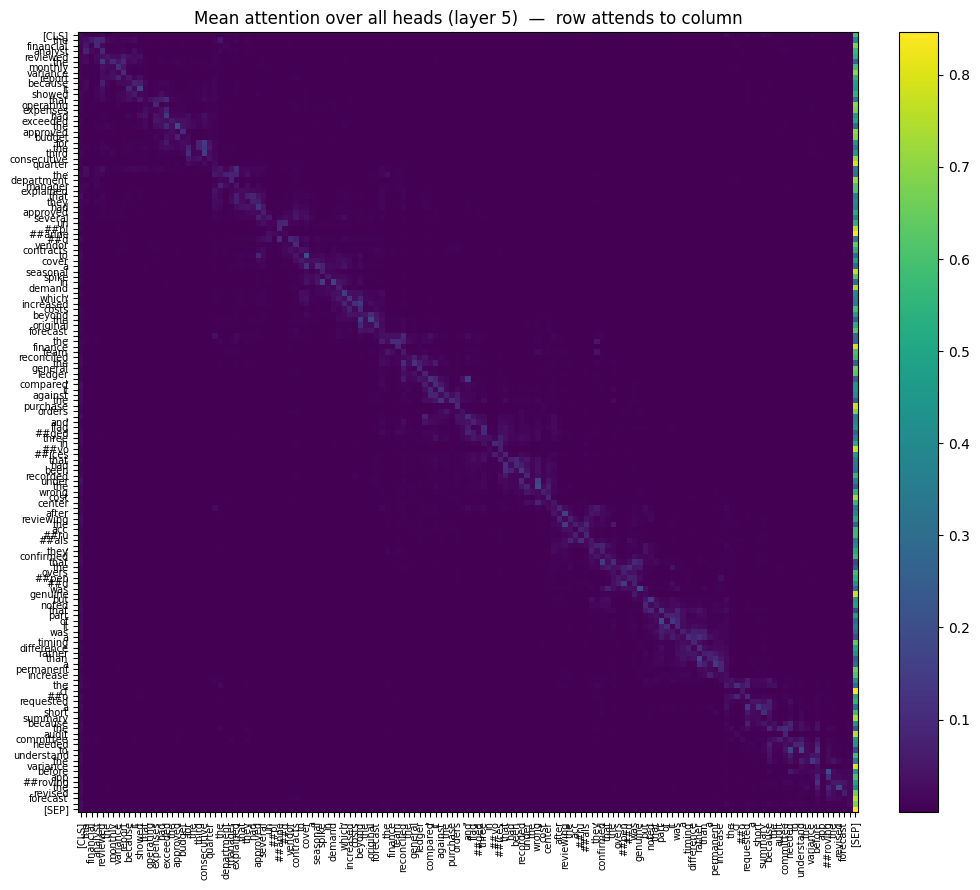

In [12]:
if MODEL_AVAILABLE:
    # outputs.attentions: tuple(num_layers) of [batch, heads, seq, seq]
    attn = outputs.attentions
    print('Num layers:', len(attn), '| shape per layer:', tuple(attn[0].shape))

    LAYER = 5            # a middle layer often carries clear syntactic/coref signal
    layer_attn = attn[LAYER][0]                  # [heads, seq, seq]
    mean_attn = layer_attn.mean(dim=0).numpy()   # average over heads -> [seq, seq]

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(mean_attn, cmap='viridis')
    ax.set_xticks(range(len(subword_tokens))); ax.set_yticks(range(len(subword_tokens)))
    ax.set_xticklabels(subword_tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(subword_tokens, fontsize=7)
    ax.set_title(f'Mean attention over all heads (layer {LAYER})  —  row attends to column')
    fig.colorbar(im, fraction=0.046, pad=0.04)

    import os
    os.makedirs('images', exist_ok=True)
    plt.tight_layout()
    plt.savefig('images/attention_heatmap.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('Run in Colab with transformers installed to see the real attention heatmap.')

### 5a. Where does **“it”** attend?
We take the first occurrence of the token `it`, average its attention over all heads and layers, and rank which tokens it looks at most. *Report* may appear near the top. **Averaging over all 144 heads dilutes coreference** (most heads attend to `[SEP]`/punctuation). The cleaner, per-head signal is what the layer/head scan in **§5b** is for.

Token 'it' at position 10 attends most to:


,attended_token,avg_attention
0,showed,0.096
1,because,0.073
2,.,0.034
3,report,0.034
4,that,0.029
5,reviewed,0.028
6,.,0.023
7,the,0.021


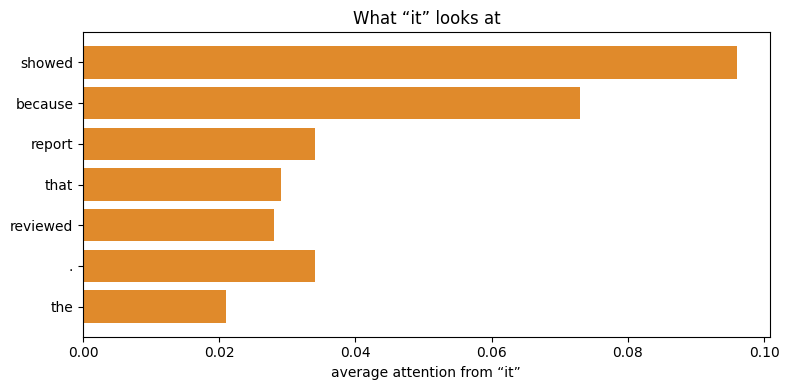

In [13]:
if MODEL_AVAILABLE:
    # locate the first 'it' token
    it_positions = [i for i, t in enumerate(subword_tokens) if t == 'it']
    if it_positions:
        it_idx = it_positions[0]
        # stack all layers -> [layers, heads, seq, seq], then average layers+heads
        all_layers = torch.stack(attn)[:, 0]        # [layers, heads, seq, seq]
        avg = all_layers.mean(dim=(0, 1)).numpy()   # [seq, seq]
        it_row = avg[it_idx]
        order = np.argsort(it_row)[::-1]
        top = [(subword_tokens[j], round(float(it_row[j]), 3))
               for j in order if subword_tokens[j] not in ('[CLS]', '[SEP]', 'it')][:8]
        print(f"Token 'it' at position {it_idx} attends most to:")
        display(pd.DataFrame(top, columns=['attended_token', 'avg_attention']))

        plt.figure(figsize=(8, 4))
        labels = [t for t, _ in top][::-1]; vals = [v for _, v in top][::-1]
        plt.barh(labels, vals, color='#e08a2b')
        plt.xlabel('average attention from \u201cit\u201d'); plt.title('What \u201cit\u201d looks at')
        plt.tight_layout(); plt.show()
    else:
        print("No standalone 'it' token found (it may have merged with punctuation).")
else:
    print('Run in Colab to inspect the attention of \u201cit\u201d.')

### 5b. High-code output — scanning layers/heads for a relationship
Scan every layer/head for the ones where **“it” attends most strongly to a `report`-related token**. Searching for interpretable heads.

In [14]:
if MODEL_AVAILABLE and it_positions:
    # target tokens that make up 'variance report'
    targets = [i for i, t in enumerate(subword_tokens) if t in ('report', 'variance')]
    rows = []
    stacked = torch.stack(attn)[:, 0]   # [layers, heads, seq, seq]
    L, H = stacked.shape[0], stacked.shape[1]
    for l in range(L):
        for h in range(H):
            w = stacked[l, h, it_idx][targets].sum().item()  # 'it' -> report/variance
            rows.append({'layer': l, 'head': h, 'it_to_report_attention': round(w, 3)})
    scan = pd.DataFrame(rows).sort_values('it_to_report_attention', ascending=False).head(5)
    scan.insert(0, 'token_analyzed', 'it')
    scan['interpretation'] = 'candidate pronoun-resolution head'
    display(scan.reset_index(drop=True))
else:
    print('Run in Colab to produce the layer/head scan table.')

,token_analyzed,layer,head,it_to_report_attention,interpretation
0,it,6,10,0.816,candidate pronoun-resolution head
1,it,8,10,0.659,candidate pronoun-resolution head
2,it,8,4,0.476,candidate pronoun-resolution head
3,it,6,4,0.376,candidate pronoun-resolution head
4,it,4,10,0.376,candidate pronoun-resolution head


## 6. Comparing attention across two sentences

The same word *it* can point to different things depending on context:

- **A:** *“...the variance report because **it** showed an overspend.”* — here *it* has a real antecedent, **report**.
- **B:** *“...the variance report because **it** was month end.”* — here *it* is closer to a temporal filler, with a weaker antecedent.

**A warning before we look.** Raw attention is a *noisy* probe of coreference. BERT-base has 144 heads and **most of them are not doing coreference** — they attend to `[SEP]`/`[CLS]` (a well-documented “null attention” sink) or to neighbouring tokens. If we **average over all 144 heads**, the small signal from the few heads that specialize in *it → report* gets washed out, and the number can look almost identical for A and B — it may not even be larger for A.

So we report **both**: the all-head **average** (diluted) *and* the single **strongest head** (where specialization shows). That contrast shows the average is not the mechanism, and attention is evidence, not proof.

In [15]:
def it_report_attention(sentence):
    """Return how much 'it' attends to 'report', per layer/head, for one sentence."""
    e = tokenizer(sentence, return_tensors='pt')
    toks = tokenizer.convert_ids_to_tokens(e['input_ids'][0])
    with torch.no_grad():
        out = model(**e)
    stacked = torch.stack(out.attentions)[:, 0]        # [layers, heads, seq, seq]
    it_pos  = [k for k, t in enumerate(toks) if t == 'it']
    rep_pos = [k for k, t in enumerate(toks) if t == 'report']
    if not it_pos or not rep_pos:
        return None
    i, r = it_pos[0], rep_pos[0]
    grid = stacked[:, :, i, r].numpy()                 # it->report for every [layer, head]
    l, h = np.unravel_index(grid.argmax(), grid.shape)
    return {'mean_all_heads': float(grid.mean()),
            'max_single_head': float(grid.max()),
            'best_layer': int(l), 'best_head': int(h)}

if MODEL_AVAILABLE:
    A = 'The financial analyst reviewed the variance report because it showed an overspend.'
    B = 'The financial analyst reviewed the variance report because it was month end.'
    rows = []
    for name, s in [('A (real antecedent)', A), ('B (filler it)', B)]:
        res = it_report_attention(s)
        if res:
            res['sentence'] = name
            rows.append(res)
    comp = pd.DataFrame(rows)[['sentence', 'mean_all_heads', 'max_single_head', 'best_layer', 'best_head']]
    display(comp.round(3))
    print('\nHow to read this critically:')
    print('- If mean_all_heads is about equal for A and B, that is the averaging washing out coreference.')
    print('- max_single_head is where a specialised head (if any) shows a cleaner A-vs-B gap.')
    print('- Either way: raw attention is evidence, not proof, of how \u201cit\u201d was resolved.')
else:
    print('Run in Colab to compare the two sentences.')

,sentence,mean_all_heads,max_single_head,best_layer,best_head
0,A (real antecedent),0.052,0.752,8,10
1,B (filler it),0.054,0.799,8,10



How to read this critically:
- If mean_all_heads is about equal for A and B, that is the averaging washing out coreference.
- max_single_head is where a specialised head (if any) shows a cleaner A-vs-B gap.
- Either way: raw attention is evidence, not proof, of how “it” was resolved.


## 7. Manual teaching matrix
A hand-scored relationship matrix — 3 = strong, 2 = moderate, 1 = weak, 0 = none. This is **not** real model output; It captures how *we* read the paragraph.

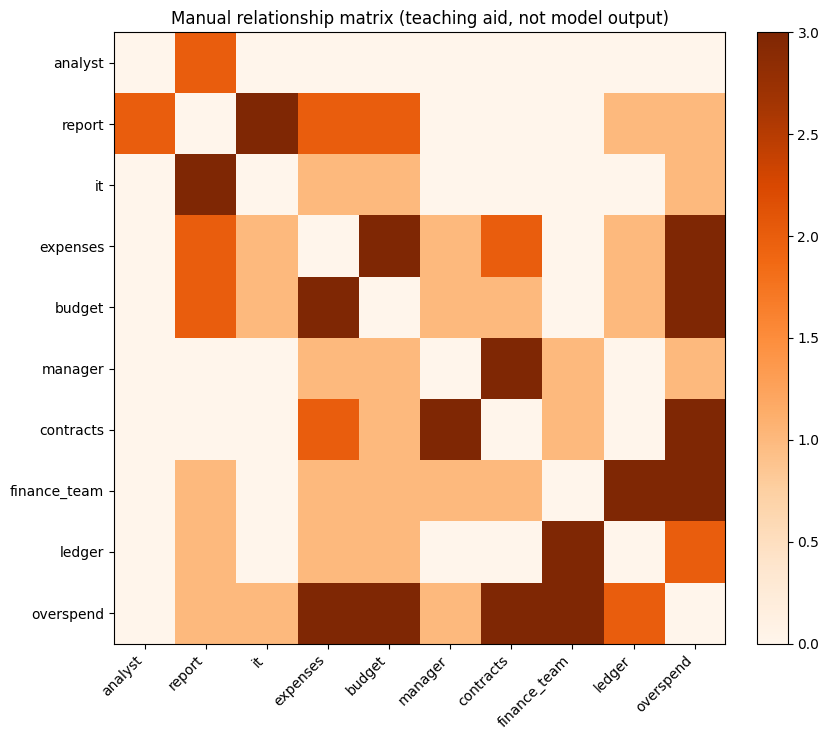

,analyst,report,it,expenses,budget,manager,contracts,finance_team,ledger,overspend
analyst,0,2,0,0,0,0,0,0,0,0
report,2,0,3,2,2,0,0,0,1,1
it,0,3,0,1,1,0,0,0,0,1
expenses,0,2,1,0,3,1,2,0,1,3
budget,0,2,1,3,0,1,1,0,1,3
manager,0,0,0,1,1,0,3,1,0,1
contracts,0,0,0,2,1,3,0,1,0,3
finance_team,0,1,0,1,1,1,1,0,3,3
ledger,0,1,0,1,1,0,0,3,0,2
overspend,0,1,1,3,3,1,3,3,2,0


In [16]:
labels = ['analyst', 'report', 'it', 'expenses', 'budget', 'manager',
          'contracts', 'finance_team', 'ledger', 'overspend']
scores = np.array([
    [0,2,0,0,0,0,0,0,0,0],   # analyst
    [2,0,3,2,2,0,0,0,1,1],   # report
    [0,3,0,1,1,0,0,0,0,1],   # it
    [0,2,1,0,3,1,2,0,1,3],   # expenses
    [0,2,1,3,0,1,1,0,1,3],   # budget
    [0,0,0,1,1,0,3,1,0,1],   # manager
    [0,0,0,2,1,3,0,1,0,3],   # contracts
    [0,1,0,1,1,1,1,0,3,3],   # finance_team
    [0,1,0,1,1,0,0,3,0,2],   # ledger
    [0,1,1,3,3,1,3,3,2,0],   # overspend
])
manual_matrix = pd.DataFrame(scores, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(scores, cmap='Oranges')
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right'); ax.set_yticklabels(labels)
ax.set_title('Manual relationship matrix (teaching aid, not model output)')
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
manual_matrix

## Part 4 — Annotated Transformer diagram
The annotated diagram is saved as **`transformer_diagram.png`** in this repository. It labels all required components:

1. Raw text input &nbsp; 2. Tokenization &nbsp; 3. Token IDs &nbsp; 4. Embeddings &nbsp; 5. Positional encoding &nbsp; 6. Self-attention &nbsp; 7. Queries, keys, values &nbsp; 8. Attention weights &nbsp; 9. Multi-head attention &nbsp; 10. Feed-forward network &nbsp; 11. Residual connections + layer normalization &nbsp; 12. Output probabilities &nbsp; 13. Generated / predicted token.

![Transformer diagram](transformer_diagram.png)

## 8. Save results
Persist the tables so they can be cited in the README or reused.

In [17]:
import os
os.makedirs('results', exist_ok=True)
context_table.to_csv('results/context_tokens.csv', index=False)
attention_behaviors.to_csv('results/attention_behaviors.csv', index=False)
manual_matrix.to_csv('results/manual_relationship_matrix.csv')
print('Saved: results/context_tokens.csv, results/attention_behaviors.csv, results/manual_relationship_matrix.csv')

Saved: results/context_tokens.csv, results/attention_behaviors.csv, results/manual_relationship_matrix.csv


## 9. Reflection


1. **Easiest relationship to identify.** Pronoun resolution was clearest **by hand**; the real model struggled. Averaged over all heads, *it* did **not** strongly favor *report*, and comparing the two sentences the strongest head barely differentiated the real antecedent from the filler *it*. Attention weight alone did not resolve the pronoun.

2. **Most ambiguous.** The two *they*'s — the model does not always separate the *department manager* from the *finance team* cleanly, because both are plausible plural agents. Humans use world knowledge (“finance teams reconcile ledgers”) that attention only partly captures.

3. **How self-attention uses context.** Each token builds a new representation as a weighted blend of every other token's Value, weighted by Query–Key similarity. That is literally *reading in context*: *it* becomes “report-flavored” because it pulled in the report's Value.

4. **Why attention is useful but not a full explanation.** Attention weights are one internal signal among many (there are also the Value vectors, the feed-forward layers, residual paths, and 144 heads whose roles overlap). A high weight is a *clue* to what the model used, not a proof of *why* it produced an output. Different heads can even disagree.

5. **How this helps me in practice.** Knowing that meaning is assembled from context helps me write clearer prompts (put the antecedent close and unambiguous), debug when a model “misreads” a pronoun, and stay skeptical of attention maps as full explanations.

## 10. Caveat — attention is not explanation
Attention heatmaps can have limitations. They show *where* information was routed, not the full computation. Values, MLP layers, and residual connections all shape the output; a token can influence the result even with low attention weight, and heads frequently encode redundant or uninterpretable patterns. These maps should be treated as **evidence to investigate** but not final answers.